In [1]:
import uuid
import gradio as gr
from graph_entity.graph import graph_builder
from IPython.display import Image, display

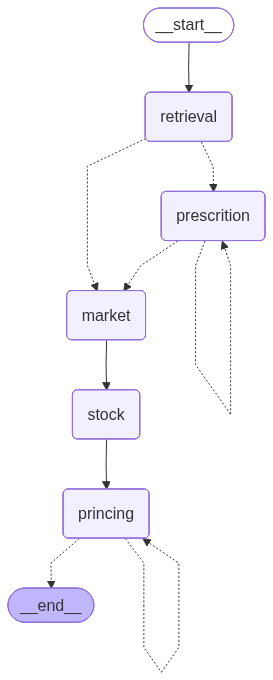

In [2]:
graph = await graph_builder()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
def thread_id_genrater() -> str:
    return str(uuid.uuid4())

In [19]:
config = {"configurable": {"thread_id": thread_id_genrater()}}
user = { "query": "How to address  Fall Army Worm disease in Maize?"}
    
result = await graph.ainvoke(user, config=config)

print(result["result"][-1].additional_kwargs.values())

# content = "\n".join(result["result"][-1].additional_kwargs.values()[0])

dict_values(['Medium', '$250–$350 per tonne', 'Fall Army Worm (FAW) outbreaks in 2025 reduced maize yields in Mozambique, driving up prices. Increased use of pesticides and biocontrol agents raised input costs, while favorable monsoons in late 2024 boosted late-season harvests, creating a temporary surplus.', 'Prices may stabilize in Q1 2025 as improved pest management curbs FAW damage, but regional drought risks could push prices higher in Q3–Q4 if rainfall remains below average.', 'Maize treated with biopesticides (e.g., *Bacillus thuringiensis*) costs 15–20% more than conventional chemical treatments, but organic alternatives like neem oil are 25–30% pricier, limiting their adoption in smallholder farms.'])


In [33]:
# test = result["result"][-1].additional_kwargs.values()

content = " \n ====== \n ".join(list(result["result"][-1].additional_kwargs.values()))

print(content)

Medium 
 $250–$350 per tonne 
 Fall Army Worm (FAW) outbreaks in 2025 reduced maize yields in Mozambique, driving up prices. Increased use of pesticides and biocontrol agents raised input costs, while favorable monsoons in late 2024 boosted late-season harvests, creating a temporary surplus. 
 Prices may stabilize in Q1 2025 as improved pest management curbs FAW damage, but regional drought risks could push prices higher in Q3–Q4 if rainfall remains below average. 
 Maize treated with biopesticides (e.g., *Bacillus thuringiensis*) costs 15–20% more than conventional chemical treatments, but organic alternatives like neem oil are 25–30% pricier, limiting their adoption in smallholder farms.


In [34]:

async def message(query, history, thread):

    config = {"configurable": {"thread_id": thread}}
    user = {"role": "user", "content": query, "query": query}
    
    result = await graph.ainvoke(user, config=config)
    
    content_ =list(result["result"][-1].additional_kwargs.values())
    
    content = " \n ----- \n ".join(content_)
    
    reply = {"role": "assistant", "content": content}
    
    return history + [user, reply]

async def reset():
    return "", "", None, thread_id_genrater()

In [35]:

with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## Personal Agro Assistant AI Supporter ")
    thread = gr.State(thread_id_genrater())
    
    with gr.Row():
        chatbot = gr.Chatbot(label="Agro Assistant AI", height=300, type="messages")
        
    with gr.Group():
        with gr.Row():
            chat_query = gr.Textbox(show_label=False, placeholder="Your query to your Agro Assistant AI system?")
            
    with gr.Row():
        reset_button = gr.Button("Reset", variant="stop")
        go_button = gr.Button("Go!", variant="primary")

    chat_query.submit(message, [chat_query, chatbot, thread], [chatbot])
    go_button.click(message, [chat_query, chatbot, thread], [chatbot])
    reset_button.click(reset, [], [chat_query, chatbot, thread])
    
demo.launch(share=True)

# How to address  Fall Army Worm disease in Maize?


* Running on local URL:  http://127.0.0.1:7869
* Running on public URL: https://8e64f6e1d836d94720.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/home/padeiroc/ai_project/agriassist-ai/.venv/lib/python3.13/site-packages/gradio/blocks.py:1924: UserWarning: A function (reset) returned too many output values (needed: 3, returned: 4). Ignoring extra values.
    Output components:
        [textbox, chatbot, state]
    Output values returned:
        ["", "", None, "f20adafc-c389-4bbd-837d-b0db397add55"]
  warnings.warn(
